# **1. 준비된 Custom Dataset 가져오기**

**1-1. 데이터 가져오기**
- VM에 dataset1.zip 파일로 업로드 후 압축 풀기

In [ ]:
import zipfile

with zipfile.ZipFile('/content/dataset1.zip') as target_file:
    target_file.extractall('/content/dataset')

- 원시 데이터셋의 개수

In [ ]:
import os

# 이미지 파일(.jpg)만 필터링하여 개수 카운팅 함수
def count_images_in_folder(folder_path, extension=".jpg"):
    return len([file for file in os.listdir(folder_path) if file.endswith(extension)])

# 폴더 경로
source_folder = '/content/dataset'

# 이미지 개수 카운팅
source_image_count = count_images_in_folder(source_folder, extension=".jpg")
print(f"Source folder contains {source_image_count} image(s).")

Source folder contains 20 image(s).


**1-2. 데이터 증식시키기**

In [ ]:
import os
import cv2
import albumentations as A
import numpy as np
import shutil
import zipfile

# 경로 설정
input_path = '/content/dataset'
output_path = '/content/aug_dataset'
os.makedirs(output_path, exist_ok=True)

# classes.txt 복사
shutil.copy(os.path.join(input_path, 'classes.txt'), os.path.join(output_path, 'classes.txt'))

# 클래스 목록 불러오기
with open(os.path.join(input_path, 'classes.txt'), 'r') as f:
    classes = [line.strip() for line in f.readlines()]
class_to_id = {cls: idx for idx, cls in enumerate(classes)}

# Albumentations 증식 설정
transform = A.Compose([
    A.HorizontalFlip(p=0.5), # 수평 뒤집기
    A.VerticalFlip(p=0.3), # 수직 뒤집기
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7), # 이동/확대/회전
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5), # 밝기/대비 조정
    A.GaussNoise(var_limit=(10, 50), p=0.3), # 가우시안 노이즈 추가
    A.MotionBlur(blur_limit=(3, 5), p=0.2), # 모션 블러
    A.GaussianBlur(blur_limit=(3, 5), p=0.2), # 가우시안 블러
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5), # 색조/채도/밝기 조정
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 증식 횟수 설정
n_copies = 25

# 전체 이미지 처리
image_files = [f for f in os.listdir(input_path) if f.endswith('.jpg')]

for image_file in image_files:
    image_path = os.path.join(input_path, image_file)
    label_path = image_path.replace('.jpg', '.txt')

    if not os.path.exists(label_path):
        print(f"Label not found for {image_file}, skipping.")
        continue

    image = cv2.imread(image_path)
    height, width = image.shape[:2]

    with open(label_path, 'r') as f:
        lines = f.read().strip().split('\n')

    bboxes = []
    class_labels = []

    for line in lines:
        if line.strip() == "":
            continue
        parts = line.strip().split()
        if len(parts) != 5:
            print(f"Invalid label format in {label_path}: {line}")
            continue
        cls_id = int(float(parts[0]))  # float로 들어온 경우 강제 int 처리
        cx, cy, w, h = map(float, parts[1:])
        bboxes.append([cx, cy, w, h])
        class_labels.append(cls_id)

    if not bboxes:
        continue

    for i in range(n_copies):
        augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        aug_image = augmented['image']
        aug_bboxes = augmented['bboxes']
        aug_labels = list(map(int, augmented['class_labels']))  # float 방지

        # bbox 범위 유효성 필터링
        filtered_bboxes = []
        filtered_labels = []

        for bbox, label in zip(aug_bboxes, aug_labels):
            cx, cy, w, h = bbox
            if 0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1:
                filtered_bboxes.append([cx, cy, w, h])
                filtered_labels.append(label)

        if not filtered_bboxes:
            continue

        # 저장 파일명 구성
        base_name = os.path.splitext(image_file)[0]
        aug_image_name = f"{base_name}_aug_{i}.jpg"
        aug_label_name = f"{base_name}_aug_{i}.txt"

        aug_image_path = os.path.join(output_path, aug_image_name)
        aug_label_path = os.path.join(output_path, aug_label_name)

        # 증식 이미지 저장
        cv2.imwrite(aug_image_path, aug_image)

        # 증식 라벨 저장 (소수점 6자리 제한)
        with open(aug_label_path, 'w') as f:
            for bbox, label in zip(filtered_bboxes, filtered_labels):
                bbox_str = ' '.join([f'{x:.6f}' for x in bbox])
                bbox_line = f"{label} {bbox_str}\n"
                f.write(bbox_line)

print("Data augmentation for YOLO format completed!")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_407/842683267.py:27: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


Data augmentation for YOLO format completed!


- 증식한 데이터셋의 개수

In [ ]:
import os

# 이미지 파일(.jpg)만 필터링하여 개수 카운팅 함수
def count_images_in_folder(folder_path, extension=".jpg"):
    return len([file for file in os.listdir(folder_path) if file.endswith(extension)])

# 폴더 경로
aug_folder = '/content/aug_dataset'

# 이미지 개수 카운팅
aug_image_count = count_images_in_folder(aug_folder, extension=".jpg")
print(f"Augmentation folder contains {aug_image_count} image(s).")

Augmentation folder contains 500 image(s).


**1-3. 증식데이터 시각화**

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# 1. 경로 및 클래스 설정
base_folder = '/content/aug_dataset'
class_file = '/content/aug_dataset/classes.txt'

with open(class_file, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

# 전체 이미지 목록 (.jpg)
image_paths = [os.path.join(base_folder, f) for f in os.listdir(base_folder) if f.endswith('.jpg')]
random_images = random.sample(image_paths, min(16, len(image_paths)))

def draw_boxes(image_path, txt_path):
    # PIL은 기본적으로 RGB로 읽습니다.
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    width, height = image.size

    if not os.path.exists(txt_path):
        return image

    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5: continue
            cls_id, cx, cy, w, h = map(float, parts)

            # YOLO 좌표 -> 픽셀 좌표 변환
            x_min = (cx - w / 2) * width
            y_min = (cy - h / 2) * height
            x_max = (cx + w / 2) * width
            y_max = (cy + h / 2) * height

            label = class_names[int(cls_id)]

            # 2. 색상 지정 (RGB 값과 주석 일치화)
            if label == 'Oriental melon':
                color = (255, 215, 0)  # 참외: 노란색 계열 (Gold)
            elif label == 'Tomato':
                color = (255, 0, 0)    # 토마토: 빨간색
            elif label == 'Apple':
                color = (0, 128, 0)    # 사과: 초록색
            else:
                color = (0, 0, 255)    # 기타: 파란색

            # BBox 그리기
            draw.rectangle([x_min, y_min, x_max, y_max], outline=color, width=3)

            # 3. 클래스 이름 표시 (텍스트 배경 박스 추가로 가독성 확보)
            text_str = f"{label}"
            # 텍스트 크기 가늠 (간단한 처리)
            text_bbox = draw.textbbox((x_min, y_min), text_str)
            draw.rectangle(text_bbox, fill=color) # 텍스트 배경
            draw.text((x_min, y_min), text_str, fill=(255, 255, 255)) # 흰색 글자

    return image

# 4. 4x4 시각화 실행
def visualize_results(image_paths):
    fig, axs = plt.subplots(4, 4, figsize=(16, 16))
    axs = axs.flatten()

    for img_path, ax in zip(image_paths, axs):
        txt_path = img_path.replace('.jpg', '.txt')
        # 이미지에 박스 그려서 가져오기
        processed_img = draw_boxes(img_path, txt_path)

        ax.imshow(processed_img) # matplotlib은 RGB를 기대함
        ax.set_title(os.path.basename(img_path), fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_results(random_images)

Output hidden; open in https://colab.research.google.com to view.

**1-4. 데이터 분할 및 학습할 YOLO 폴더 구조 갖추기**

In [ ]:
import os
import shutil

current_path = os.path.abspath(os.curdir)
data_path = current_path + '/aug_dataset'

test_percentage = 0.2  # test dataset percentage
val_percentage = 0.1   # val dataset percentage

image_paths = []
label_paths = []

# 데이터 분할
os.chdir(data_path)
for current_dir, dirs, files in os.walk('.'):
    for f in files:
        if f.endswith('.jpg'):
            image_path = current_path + '/aug_dataset/' + f
            image_paths.append(image_path)
            fn = f.split('.')
            label_path = current_path + '/aug_dataset/' + fn[0] + '.txt'
            label_paths.append(label_path)

# test dataset
image_paths_test = image_paths[:int(len(image_paths) * test_percentage)]
label_paths_test = label_paths[:int(len(label_paths) * test_percentage)]

# train dataset
image_paths = image_paths[int(len(image_paths) * test_percentage):]
label_paths = label_paths[int(len(label_paths) * test_percentage):]

# train dataset에서 다시 val dataset으로 분할
image_paths_val = image_paths[:int(len(image_paths) * val_percentage)]
label_paths_val = label_paths[:int(len(label_paths) * val_percentage)]

# 최종적인 train dataset
image_paths_train = image_paths[int(len(image_paths) * val_percentage):]
label_paths_train = label_paths[int(len(label_paths) * val_percentage):]

# train dataset 준비
if not os.path.exists('/content/yolo_dataset/train'):
  os.makedirs('/content/yolo_dataset/train/images')
  os.makedirs('/content/yolo_dataset/train/labels')

  for _source in image_paths_train:
    shutil.copy(_source, '/content/yolo_dataset/train/images')

  for _source in label_paths_train:
    shutil.copy(_source, '/content/yolo_dataset/train/labels')

# val dataset 준비
if not os.path.exists('/content/yolo_dataset/val'):
  os.makedirs('/content/yolo_dataset/val/images')
  os.makedirs('/content/yolo_dataset/val/labels')

  for _source in image_paths_val:
    shutil.copy(_source, '/content/yolo_dataset/val/images')

  for _source in label_paths_val:
    shutil.copy(_source, '/content/yolo_dataset/val/labels')

# test dataset 준비
if not os.path.exists('/content/yolo_dataset/test'):
  os.makedirs('/content/yolo_dataset/test/images')
  os.makedirs('/content/yolo_dataset/test/labels')

  for _source in image_paths_test:
    shutil.copy(_source, '/content/yolo_dataset/test/images')

  for _source in label_paths_test:
    shutil.copy(_source, '/content/yolo_dataset/test/labels')

# 작업 디렉토리를 다시 /content 로 변경
os.chdir('/content')

In [ ]:
# 폴더의 내용을 tree 구조로 볼 수 있도록 하는 패키지 설치
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (69.4 kB/s)
Selecting previously unselected package tree.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
yolo_root = "/content/yolo_dataset/"
print("YOLO Dataset 구조 :\n")
!tree {yolo_root} -d

YOLO Dataset 구조 :

/content/yolo_dataset/
├── test
│   ├── images
│   └── labels
├── train
│   ├── images
│   └── labels
└── val
    ├── images
    └── labels

9 directories


# **2. Custom yaml 파일을 만들자.**

In [ ]:
# PyYAML을 설치하자
!pip install PyYAML

In [ ]:
import yaml

data_cf = {'train' : '/content/yolo_dataset/train/images',
           'val' : '/content/yolo_dataset/test/images',
           'names' : ['Oriental melon', 'Tomato', 'Apple'],
           'nc' : 3 }

# fruit_data.yaml 이란 이름으로 custom yaml 파일을 만든다.
with open('/content/yolo_dataset/fruit_data.yaml', 'w') as f:
  yaml.dump(data_cf, f)

# fruit_data.yaml 확인
with open('/content/yolo_dataset/fruit_data.yaml', 'r') as f:
  fruit_yaml = yaml.safe_load(f)
  display(fruit_yaml)

{'names': ['Oriental melon', 'Tomato', 'Apple'],
 'nc': 3,
 'train': '/content/yolo_dataset/train/images',
 'val': '/content/yolo_dataset/test/images'}

# **3. YOLO26을 사용하기 위한 Setup(셋업)**

In [ ]:
# ultralytics 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.4 MB/s eta 0:00:00


In [ ]:
# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.1/112.6 GB disk)


# **4. Custom YOLO26 Training(학습)**

**Detection 모델로 사용할 수 있는 모델의 종류**

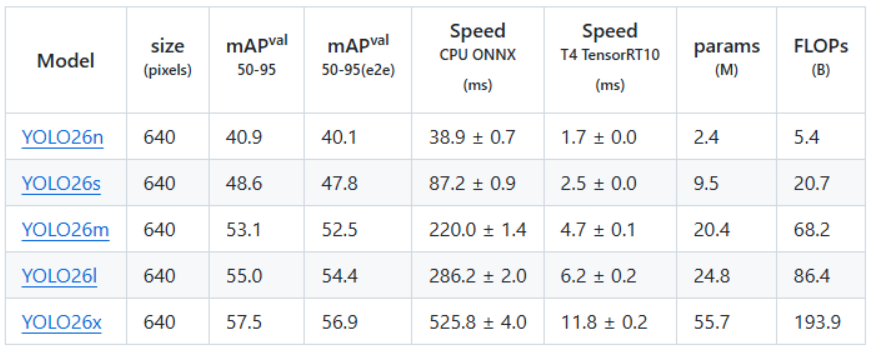

In [ ]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# yolo26n.pt 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('yolo26n.pt')

In [ ]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

**불러온 모델 아키텍처를 이용하여 우리가 준비한 Custom Dataset으로 학습을 시켜보자.**

In [ ]:
model.train(data='/content/yolo_dataset/fruit_data.yaml', epochs=100, patience=5, batch=8, imgsz=640)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/fruit_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d07180ff530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# **5. Training(학습) 결과 확인**

**학습 결과를 그래프로 저장한 파일을 통해 확인해 본다**

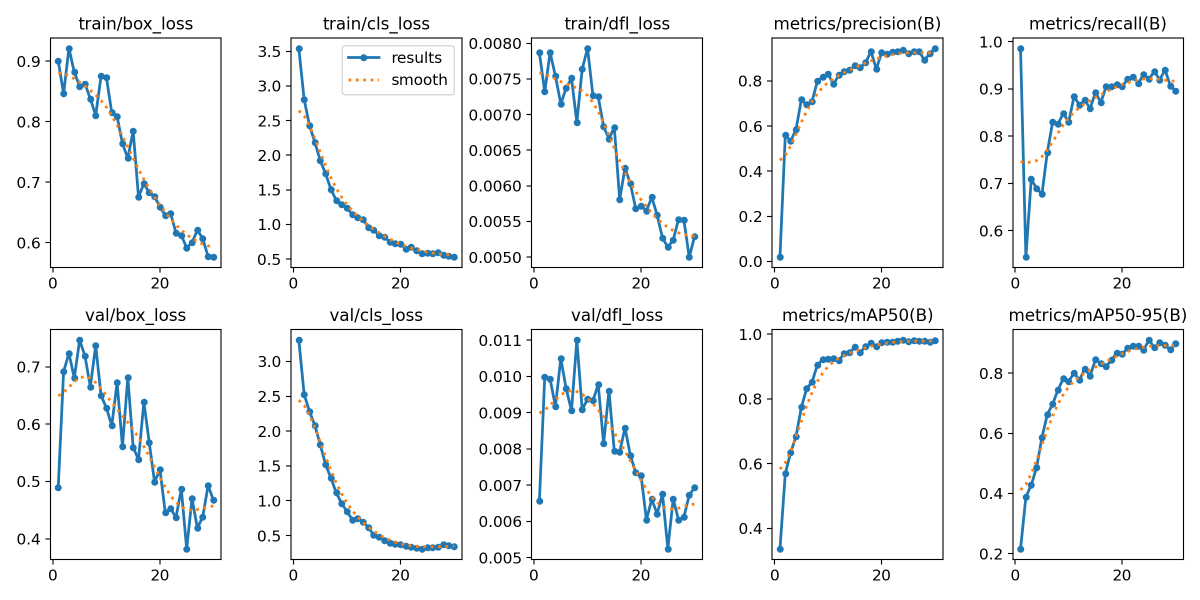

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

result_img = cv2.imread('/content/runs/detect/train2/results.png')
fix_width = 1200
height,width = result_img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
result_img = cv2.resize(result_img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(result_img)

**Custom 모델이 분류할 수 있는 부류 확인**

In [ ]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 3
{0: 'Oriental melon', 1: 'Tomato', 2: 'Apple'}


# **6. Custom 모델로 Detection(검출)**

**Image Detection**

In [ ]:
# 모델 예측
results = model.predict(source='/content/yolo_dataset/test/images/fruit04_aug_18.jpg', save=True)


image 1/1 /content/yolo_dataset/test/images/fruit04_aug_18.jpg: 480x640 2 Oriental melons, 9 Tomatos, 10 Apples, 70.5ms
Speed: 3.6ms preprocess, 70.5ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


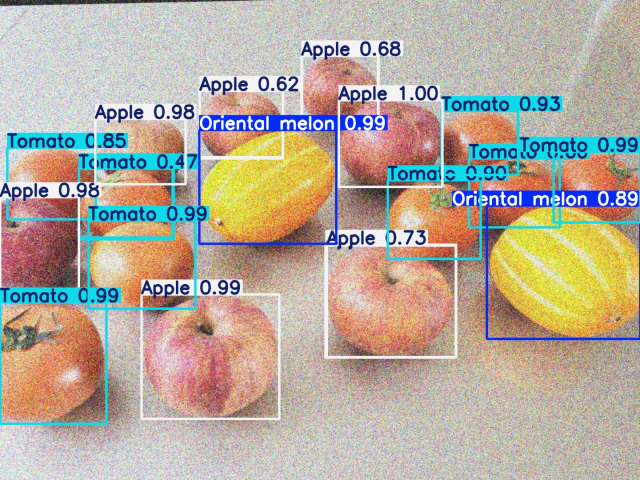

In [ ]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/detect/predict/fruit04_aug_18.jpg')
fix_width = 640
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)

**Video Detection**

In [ ]:
# 동영상 예측
results = model.predict(source='/content/fruit.mp4', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/892) /content/fruit.mp4: 384x640 1 Oriental melon, 60.0ms
video 1/1 (frame 2/892) /content/fruit.mp4: 384x640 1 Oriental melon, 11.5ms
video 1/1 (frame 3/892) /content/fruit.mp4: 384x640 1 Oriental melon, 11.4ms
video 1/1 (frame 4/892) /content/fruit.mp4: 384x640 1 Oriental melon, 10.2ms
video 1/1 (frame 5/892) /content/fruit.mp4: 384x640 1 Oriental melon, 14.2ms
video 1/1 (frame 6/892) /content/fruit.mp4: 384x640 1 Oriental melon, 12.

In [ ]:
# 코랩에서 영상을 보여줄 준비
import io
from IPython.display import HTML
from base64 import b64encode
def show_video(file_name, width=640):
  # show resulting deepsort video
  mp4 = open(file_name,'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
  return HTML("""
  <video width="{0}" controls>
        <source src="{1}" type="video/mp4">
  </video>
  """.format(width, data_url))

In [ ]:
# avi 파일을 mp4 파일로 변환 후 영상을 보여줌
import os
path_video = os.path.join("/content/runs/detect/predict","fruit.avi")
%cd /content/runs/detect/predict
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!ffmpeg -y -loglevel panic -i "fruit.avi" "fruit.mp4"
%cd ../../../

# output object tracking video
path_output = os.path.join("/content/runs/detect/predict","fruit.mp4")
show_video(path_output, width=640)

Output hidden; open in https://colab.research.google.com to view.

# **7. 학습된 모델을 불러와 검출**

In [ ]:
# ultralytics 설치
!pip install ultralytics

# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.2/112.6 GB disk)


In [ ]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# 학습된 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('/content/runs/detect/train2/weights/best.pt')

In [ ]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 3
{0: 'Oriental melon', 1: 'Tomato', 2: 'Apple'}


In [ ]:
# 모델 예측
results = model.predict(source='/content/yolo_dataset/test/images/fruit15_aug_23.jpg', save=True)


image 1/1 /content/yolo_dataset/test/images/fruit15_aug_23.jpg: 480x640 1 Oriental melon, 11 Tomatos, 3 Apples, 22.9ms
Speed: 3.9ms preprocess, 22.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict2


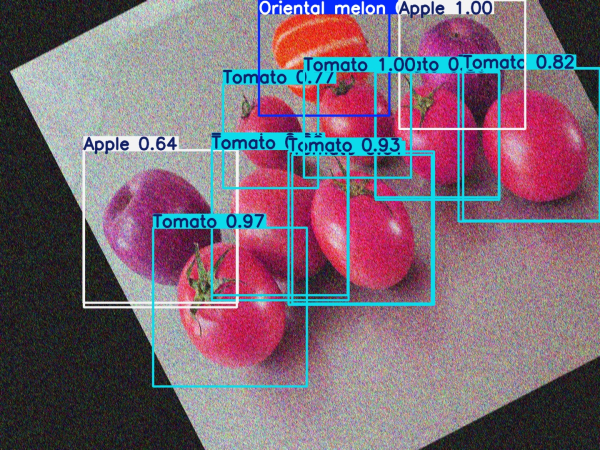

In [ ]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/detect/predict2/fruit15_aug_23.jpg')
fix_width = 600
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)